In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score
)

In [4]:
df = pd.read_csv("heart_disease_uci.csv")

df.head()

,id,age,sex,dataset,cp,...,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,...,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,...,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,...,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,...,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,...,1.4,upsloping,0.0,normal,0


In [5]:
print("Dataset shape:", df.shape)

Dataset shape: (920, 16)


In [6]:
print(df.columns)

Index(['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs',
       'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num'],
      dtype='str')


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    str    
 3   dataset   920 non-null    str    
 4   cp        920 non-null    str    
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    str    
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    str    
 13  ca        309 non-null    float64
 14  thal      434 non-null    str    
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(2), str(6)
memory usage: 156.4+ KB


In [8]:
print(df.columns.tolist())

['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']


In [9]:
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [10]:
df.isnull().sum()

id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    str    
 3   dataset   920 non-null    str    
 4   cp        920 non-null    str    
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    str    
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    str    
 13  ca        309 non-null    float64
 14  thal      434 non-null    str    
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(2), str(6)
memory usage: 156.4+ KB


In [12]:
df = df.drop(['id', 'dataset'], axis=1)

In [13]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,63,Male,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,67,Male,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,67,Male,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,37,Male,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,41,Female,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [ ]:
The ca feature contained a large number of missing values. Instead of removing the feature, missing values were imputed using the median

In [14]:
df['ca'] = df['ca'].fillna(df['ca'].median())

In [15]:
print(df['ca'].isnull().sum())

0


In [16]:
# Handle missing numerical values
numerical_columns = [
    'trestbps',
    'chol',
    'thalch',
    'oldpeak',
    'ca'
]

for column in numerical_columns:
    df[column] = df[column].fillna(df[column].median())

In [17]:
categorical_columns = [
    'sex',
    'cp',
    'fbs',
    'restecg',
    'exang',
    'slope',
    'thal'
]

for column in categorical_columns:
    df[column] = df[column].fillna(df[column].mode()[0])

In [18]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
num         0
dtype: int64

In [ ]:
num column contains:
0, 1, 2, 3, 4 etc
Converting num into a binary target:
0 → No heart disease
1,2,3,4 → Heart disease    

In [19]:
df['num'] = df['num'].apply(lambda x: 1 if x > 0 else 0)

In [20]:
df['num'].value_counts()

num
1    509
0    411
Name: count, dtype: int64

In [ ]:
Separating features and target

In [21]:
X = df.drop('num', axis=1)
y = df['num']

In [22]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (920, 13)
y shape: (920,)


In [ ]:
Encoding categorical columns
categorical columns contain text values such as:
sex
cp
restecg
slope
thal

In [ ]:
Using one-hot encoding

In [23]:
X = pd.get_dummies(X, drop_first=True)

In [24]:
X.head()

,age,trestbps,chol,thalch,oldpeak,ca,sex_Male,cp_atypical angina,cp_non-anginal,cp_typical angina,fbs_True,restecg_normal,restecg_st-t abnormality,exang_True,slope_flat,slope_upsloping,thal_normal,thal_reversable defect
0,63,145.0,233.0,150.0,2.3,0.0,True,False,False,True,True,False,False,False,False,False,False,False
1,67,160.0,286.0,108.0,1.5,3.0,True,False,False,False,False,False,False,True,True,False,True,False
2,67,120.0,229.0,129.0,2.6,2.0,True,False,False,False,False,False,False,True,True,False,False,True
3,37,130.0,250.0,187.0,3.5,0.0,True,False,True,False,False,True,False,False,False,False,True,False
4,41,130.0,204.0,172.0,1.4,0.0,False,True,False,False,False,False,False,False,False,True,True,False


In [25]:
print("X shape:", X.shape)

X shape: (920, 18)


In [26]:
print(X.dtypes)

age                           int64
trestbps                    float64
chol                        float64
thalch                      float64
oldpeak                     float64
ca                          float64
sex_Male                       bool
cp_atypical angina             bool
cp_non-anginal                 bool
cp_typical angina              bool
fbs_True                       bool
restecg_normal                 bool
restecg_st-t abnormality       bool
exang_True                     bool
slope_flat                     bool
slope_upsloping                bool
thal_normal                    bool
thal_reversable defect         bool
dtype: object


In [27]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (920, 18)
y shape: (920,)


In [ ]:
Split the data into training and testing sets

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [29]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (736, 18)
X_test: (184, 18)
y_train: (736,)
y_test: (184,)


In [ ]:
Feature Scaling

In [ ]:
scaling the features for Logistic Regression

In [30]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [31]:
print("Scaled training data shape:", X_train_scaled.shape)
print("Scaled testing data shape:", X_test_scaled.shape)

Scaled training data shape: (736, 18)
Scaled testing data shape: (184, 18)


In [ ]:
Training  Logistic Regression

In [33]:
from sklearn.linear_model import LogisticRegression
logistic_model = LogisticRegression(max_iter=1000)
logistic_model.fit(X_train_scaled, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [ ]:
Making Predictions: predict 0 or 1 

In [34]:
y_pred_lr = logistic_model.predict(X_test_scaled)

In [ ]:
Prediction Probabilities

In [35]:
y_prob_lr = logistic_model.predict_proba(X_test_scaled)[:, 1]

In [36]:
print("Predicted:", y_pred_lr[:10])
print("Actual:   ", y_test.values[:10])

Predicted: [0 1 1 1 0 1 1 1 0 0]
Actual:    [1 1 1 1 0 0 0 1 0 1]


In [37]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)

print("Logistic Regression Results")
print("----------------------------")
print("Accuracy :", accuracy_lr)
print("Precision:", precision_lr)
print("Recall   :", recall_lr)

Logistic Regression Results
----------------------------
Accuracy : 0.842391304347826
Precision: 0.8411214953271028
Recall   : 0.8823529411764706


In [ ]:
Confusion Matrix

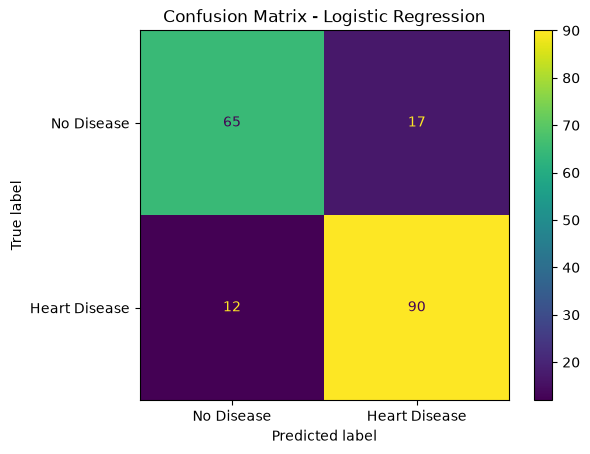

In [38]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_lr)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['No Disease', 'Heart Disease']
)

disp.plot()

plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [ ]:
ROC curve

In [ ]:
The ROC curve shows how well the model separates:
    
No Heart Disease
        vs
Heart Disease

The AUC value closer to 1 generally indicates better discrimination

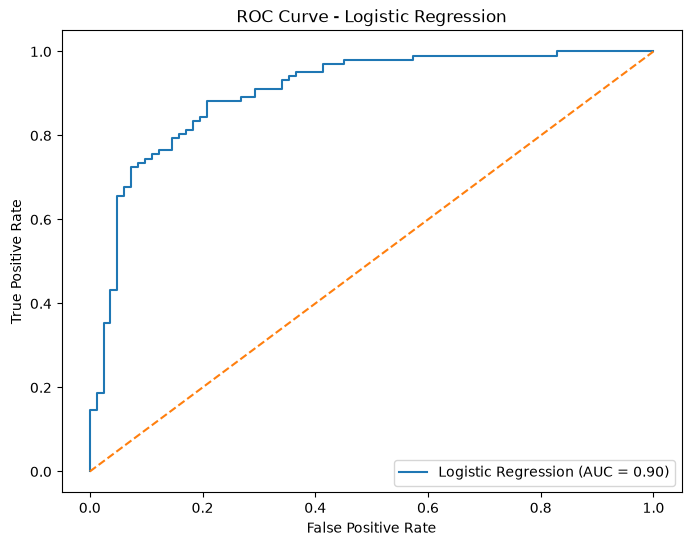

ROC-AUC Score: 0.9031563845050216


In [39]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(y_test, y_prob_lr)

auc_score = roc_auc_score(y_test, y_prob_lr)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {auc_score:.2f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()

plt.show()

print("ROC-AUC Score:", auc_score)

In [ ]:
We are now going to compare two algorithms or model:Logistic Regression  and Decision Tree, training both and comparing them
to identify which one will be the best for this project prediction

In [40]:
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

tree_model.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at 

In [41]:
y_pred_tree = tree_model.predict(X_test)

In [42]:
accuracy_tree = accuracy_score(y_test, y_pred_tree)
precision_tree = precision_score(y_test, y_pred_tree)
recall_tree = recall_score(y_test, y_pred_tree)

print("Decision Tree Results")
print("---------------------")
print("Accuracy :", accuracy_tree)
print("Precision:", precision_tree)
print("Recall   :", recall_tree)

Decision Tree Results
---------------------
Accuracy : 0.782608695652174
Precision: 0.803921568627451
Recall   : 0.803921568627451


In [ ]:
Comparing both models

In [43]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree'],
    'Accuracy': [accuracy_lr, accuracy_tree],
    'Precision': [precision_lr, precision_tree],
    'Recall': [recall_lr, recall_tree]
})

results

,Model,Accuracy,Precision,Recall
0,Logistic Regression,0.842391,0.841121,0.882353
1,Decision Tree,0.782609,0.803922,0.803922


In [ ]:
Logistic Regression is performing better than the Decision Tree on all three metrics, so Logistic Regression as the final best-performing model

In [ ]:
Accuracy: Logistic Regression correctly classified about 84% of the test patients.
Precision: When Logistic Regression predicted heart disease, it was correct about 84% of the time.
Recall: It detected about 88% of the patients who actually had heart disease

In [ ]:
final model comparison visualization

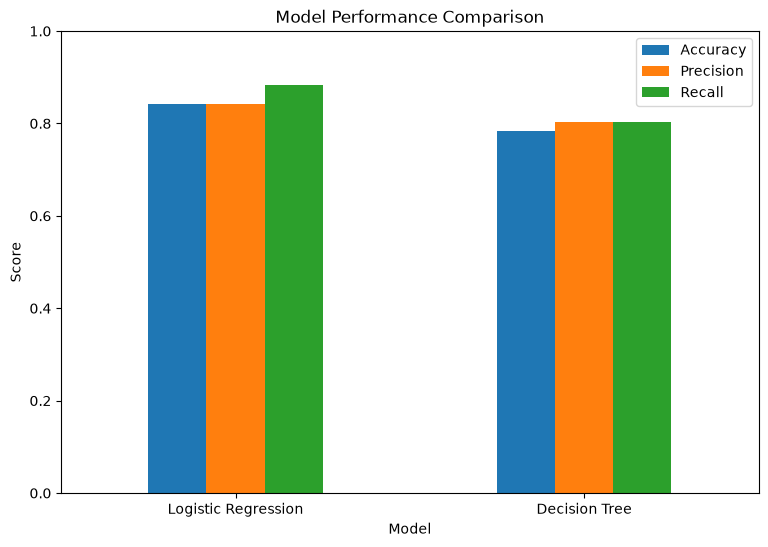

In [44]:
results_plot = results.set_index('Model')

results_plot[['Accuracy', 'Precision', 'Recall']].plot(
    kind='bar',
    figsize=(9, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend()
plt.show()

In [ ]:
Since Logistic Regression performed better, so we will generate confusion matrix for Logistic Regression as 
the main confusion matrix for our project

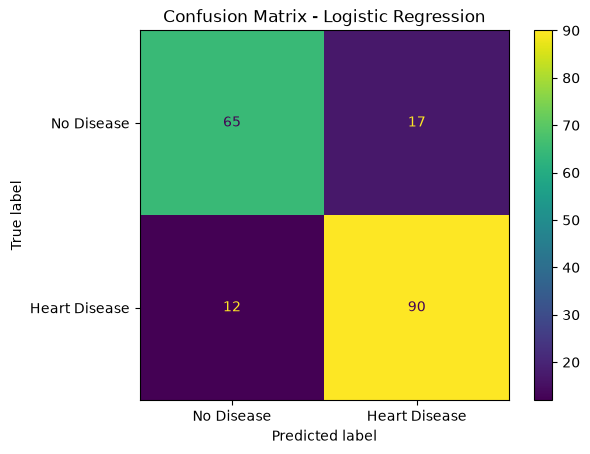

In [46]:
cm = confusion_matrix(y_test, y_pred_lr)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['No Disease', 'Heart Disease']
)

disp.plot()

plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [ ]:
ROC Curve for final  Logistic Regression model

In [47]:
y_prob_lr

array([0.45029291, 0.94885876, 0.86431253, 0.92806065, 0.39390558,
       0.61843205, 0.6627998 , 0.94668151, 0.14759058, 0.39075243,
       0.14586316, 0.0513254 , 0.00829284, 0.11554992, 0.96900791,
       0.95817108, 0.04299868, 0.8875839 , 0.32844591, 0.23085885,
       0.91795073, 0.96891457, 0.0267378 , 0.12591127, 0.98440764,
       0.91187122, 0.12063649, 0.85152799, 0.2453054 , 0.02013802,
       0.19254994, 0.32690297, 0.49710119, 0.71227451, 0.92744569,
       0.81283579, 0.76860064, 0.91502042, 0.05678753, 0.05784012,
       0.91773882, 0.99449636, 0.95994763, 0.2063354 , 0.79864659,
       0.98178287, 0.85384831, 0.79329368, 0.68042259, 0.77408599,
       0.28853866, 0.69319513, 0.1079019 , 0.11841646, 0.76089557,
       0.13528863, 0.96659418, 0.10428968, 0.43541837, 0.0191293 ,
       0.2620558 , 0.89307947, 0.28956387, 0.87407268, 0.08479534,
       0.65592844, 0.32436513, 0.56721817, 0.08163603, 0.06210466,
       0.73719471, 0.54135873, 0.19495146, 0.98078719, 0.10000

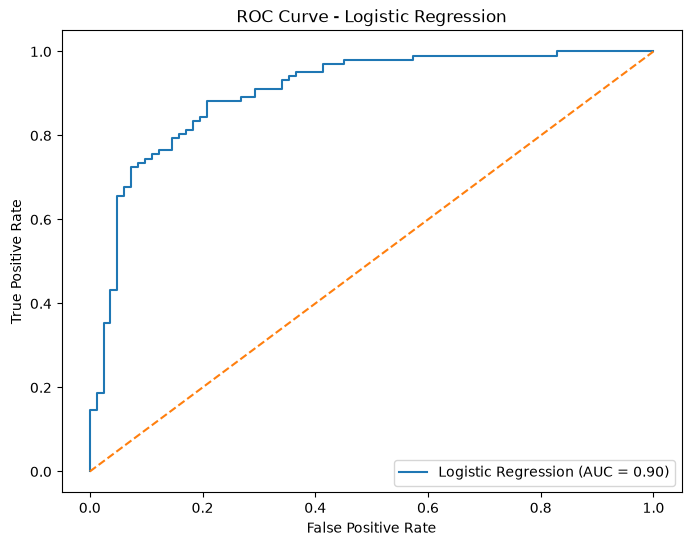

ROC-AUC Score: 0.9031563845050216


In [48]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob_lr)

auc_score = roc_auc_score(y_test, y_prob_lr)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {auc_score:.2f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()

plt.show()

print("ROC-AUC Score:", auc_score)

In [ ]:
Outcome:Predicting if patient likely to have heart disease

In [50]:
sample = X_test.iloc[0:1]

sample_scaled = scaler.transform(sample)

prediction = logistic_model.predict(sample_scaled)[0]
probability = logistic_model.predict_proba(sample_scaled)[0][1]

if prediction == 1:
    print("Prediction: Likely Heart Disease")
else:
    print("Prediction: No Heart Disease")

print("Probability of Heart Disease:", probability)
print("Probability (%):", probability * 100)

Prediction: No Heart Disease
Probability of Heart Disease: 0.45029290602847
Probability (%): 45.029290602847


In [ ]:
Saving the whole prediction project  in separate csv file

In [51]:
predictions = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred_lr
})

predictions.to_csv(
    'heart_disease_predictions.csv',
    index=False
)

print("Predictions saved successfully!")

Predictions saved successfully!
